# 10_Skill_Archetype_Clustering_Final
Improved clustering with proper normalization, PCA visualization, manual archetype interpretation, and final v8 export.

In [1]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df = pd.read_csv('../Generated Datasets/expanded_skill_master.csv')

print("Shape:", df.shape)

important = [
    'langchain',
    'llm',
    'rag',
    'tableau',
    'power bi'
]

print("\nImportant skills check:")
print(df[df['skill'].str.lower().isin(important)])


Shape: (114, 9)

Important skills check:
       skill    sub_category  linkedin_demand  salary_premium  current_usage  \
22   tableau  Data Analytics         0.085733        0.420975       0.343470   
32  power bi  Data Analytics         0.066236        0.349460       0.270022   

    future_interest  global_adoption_score  growth_rate  history_found  
22         0.310487                  155.8     0.566533              1  
32         0.257822                  162.5     0.566533              1  


In [3]:

if 'global_adoption_score.1' in df.columns:
    df = df.drop(columns=['global_adoption_score.1'])

df = df.loc[:, ~df.columns.duplicated()]

df['global_adoption_score'] = MinMaxScaler().fit_transform(
    df[['global_adoption_score']]
)


In [4]:

feature_cols = [
    'linkedin_demand',
    'salary_premium',
    'current_usage',
    'future_interest',
    'global_adoption_score',
    'growth_rate'
]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


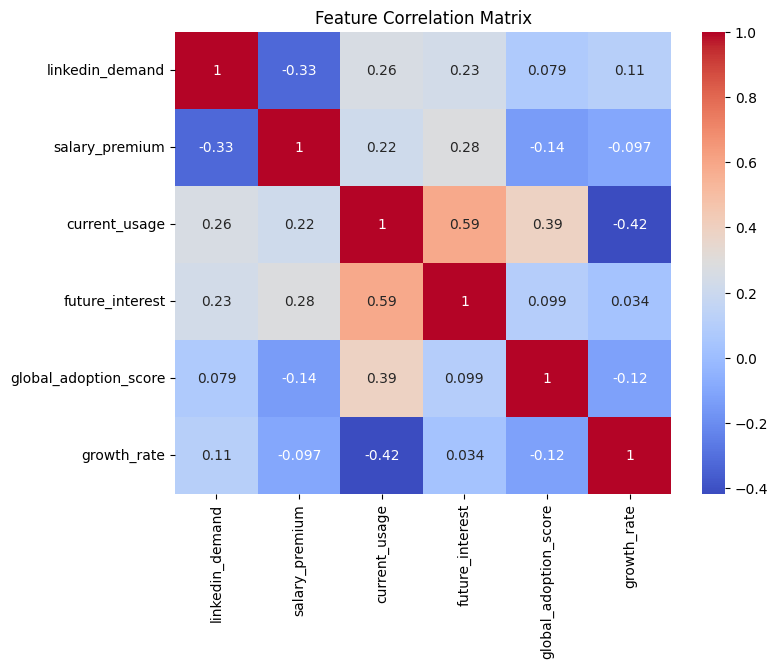

In [5]:

plt.figure(figsize=(8,6))
sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Feature Correlation Matrix')
plt.show()


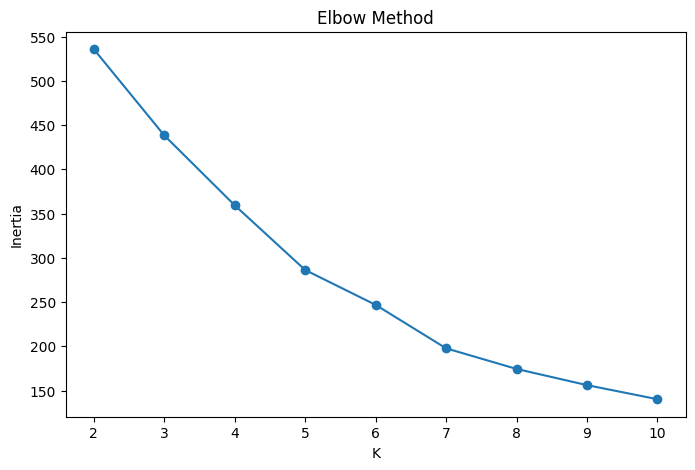

In [6]:

inertias=[]

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()


In [7]:

scores=[]

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    scores.append(
        silhouette_score(X_scaled, labels)
    )

sil_df = pd.DataFrame({
    'K': range(2,11),
    'Silhouette': scores
})

display(sil_df.sort_values(
    'Silhouette',
    ascending=False
))


,K,Silhouette
0,2,0.378971
6,8,0.357936
5,7,0.354563
4,6,0.337135
3,5,0.323862
2,4,0.301651
7,9,0.291702
8,10,0.283934
1,3,0.271883


In [8]:

final_k = 4

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

df['cluster'] = kmeans.fit_predict(X_scaled)

print(df['cluster'].value_counts())


cluster
2    55
1    42
0    10
3     7
Name: count, dtype: int64


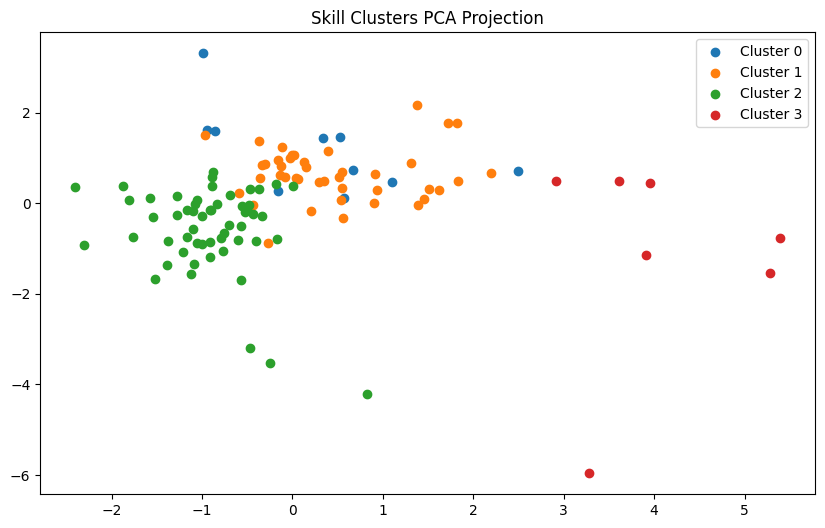

In [9]:

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

df['pc1'] = components[:,0]
df['pc2'] = components[:,1]

plt.figure(figsize=(10,6))

for cluster in sorted(df['cluster'].unique()):

    subset = df[df['cluster']==cluster]

    plt.scatter(
        subset['pc1'],
        subset['pc2'],
        label=f'Cluster {cluster}'
    )

plt.legend()
plt.title('Skill Clusters PCA Projection')
plt.show()


In [10]:

cluster_summary = (
    df.groupby('cluster')[feature_cols]
    .mean()
    .round(3)
)

display(cluster_summary)


,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
cluster,,,,,,
0,0.042,0.820,0.301,0.600,0.512,0.635
1,0.043,0.622,0.386,0.311,0.632,0.200
2,0.075,0.447,0.248,0.251,0.633,0.532
3,0.261,0.579,0.796,0.632,0.802,0.282


## Manual Archetype Interpretation


## Cluster Interpretation Summary

| Cluster | Archetype | LinkedIn Demand | Salary Premium | Current Usage | Future Interest | Global Adoption | Growth Rate | Interpretation |
|----------|----------|----------|----------|----------|----------|----------|----------|----------|
| Cluster 0 | Growing | Low | Very High | Medium | High | Medium | High | Specialized, high-value technologies with strong salary premiums, workforce growth, and future potential. |
| Cluster 1 | Stable | Low | High | Medium | Low | High | Very Low | Mature technologies with widespread adoption and stable demand but limited future growth. |
| Cluster 2 | High-Risk | Low | Medium | Low | Low | High | Medium | Technologies with weaker workforce demand signals, lower usage, and reduced future interest despite existing adoption. |
| Cluster 3 | Future-Proof | Very High | High | Very High | Very High | Very High | Medium | Core technologies with dominant workforce demand, strong adoption, and long-term relevance. |

In [11]:
cluster_summary

,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
cluster,,,,,,
0,0.042,0.820,0.301,0.600,0.512,0.635
1,0.043,0.622,0.386,0.311,0.632,0.200
2,0.075,0.447,0.248,0.251,0.633,0.532
3,0.261,0.579,0.796,0.632,0.802,0.282


In [12]:
archetype_map = {
    3: "Future-Proof",
    0: "Growing",
    1: "Stable",
    2: "High-Risk"
}

df['archetype'] = df['cluster'].map(archetype_map)

print(df['archetype'].value_counts())


archetype
High-Risk       55
Stable          42
Growing         10
Future-Proof     7
Name: count, dtype: int64


In [13]:
df.groupby('archetype')['skill'].apply(list).head()

archetype
Future-Proof    [data analysis, python, sql, javascript, docke...
Growing         [machine learning, kubernetes, data science, a...
High-Risk       [excel, quality assurance, microsoft excel, el...
Stable          [java, aws, linux, cloud computing, azure, c++...
Name: skill, dtype: object

In [14]:

for c in sorted(df['cluster'].unique()):

    print(f'\n===== CLUSTER {c} =====')

    display(
        df[df['cluster']==c]
        .sort_values(
            'linkedin_demand',
            ascending=False
        )[[
            'skill',
            'linkedin_demand',
            'future_interest',
            'growth_rate',
            'archetype'
        ]].head(10)
    )



===== CLUSTER 0 =====


,skill,linkedin_demand,future_interest,growth_rate,archetype
13,machine learning,0.119406,0.646826,0.701560,Growing
24,kubernetes,0.081877,0.382577,0.368568,Growing
38,data science,0.058758,0.720376,0.701560,Growing
42,artificial intelligence,0.054658,0.497480,0.701560,Growing
84,github,0.021326,1.000000,0.368568,Growing
89,deep learning,0.018935,0.543536,0.701560,Growing
94,pytorch,0.017727,0.512933,1.000000,Growing
98,computer vision,0.016605,0.572054,0.701560,Growing
100,tensorflow,0.016239,0.554918,0.403120,Growing
106,natural language processing,0.013299,0.564760,0.701560,Growing



===== CLUSTER 1 =====


,skill,linkedin_demand,future_interest,growth_rate,archetype
8,java,0.169477,0.281397,0.059115,Stable
9,aws,0.155410,0.409682,0.007891,Stable
19,linux,0.095993,0.377007,0.368568,Stable
20,cloud computing,0.091345,0.374111,0.130890,Stable
21,azure,0.088624,0.334348,0.130890,Stable
25,c++,0.081182,0.296198,0.131024,Stable
26,devops,0.077009,0.347952,0.368568,Stable
30,git,0.072093,0.326397,0.368568,Stable
35,programming,0.064309,0.386355,0.131024,Stable
39,c#,0.057623,0.345574,0.131024,Stable



===== CLUSTER 2 =====


,skill,linkedin_demand,future_interest,growth_rate,archetype
1,excel,0.506295,0.535307,0.566533,High-Risk
2,quality assurance,0.442621,0.305183,0.566533,High-Risk
3,microsoft excel,0.314443,0.394582,0.566533,High-Risk
6,electrical engineering,0.205053,0.131057,0.566533,High-Risk
7,mechanical engineering,0.187546,0.178096,0.566533,High-Risk
10,agile,0.140440,0.213647,0.566533,High-Risk
11,software development,0.127434,0.266445,0.566533,High-Risk
12,testing,0.121712,0.216942,0.566533,High-Risk
15,automation,0.113757,0.330555,0.566533,High-Risk
16,data analytics,0.105973,0.242801,0.566533,High-Risk



===== CLUSTER 3 =====


,skill,linkedin_demand,future_interest,growth_rate,archetype
0,data analysis,1.000000,0.559777,0.566533,Future-Proof
4,python,0.307062,0.701599,0.255955,Future-Proof
5,sql,0.268838,0.635953,0.282090,Future-Proof
14,javascript,0.115307,0.597763,0.080145,Future-Proof
27,docker,0.076302,0.691656,0.251078,Future-Proof
55,typescript,0.039029,0.570533,0.264992,Future-Proof
87,postgresql,0.019692,0.670188,0.271564,Future-Proof


In [15]:

df.to_csv(
    '../Generated Datasets/master_skill_dataset_v8.csv',
    index=False
)

cluster_summary.to_csv(
    '../Generated Datasets/cluster_summary.csv'
)

print('Saved Successfully')
print(df.shape)


Saved Successfully
(114, 13)
